# Блок 1. Загрузка данных

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
SEED = 42

In [3]:
data = pd.read_csv("geo-reviews-dataset-2023.csv")

In [4]:
data.head(5)

,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3.0,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...


In [5]:
data.shape

(500000, 5)

# Блок 2. Базовая предобработка данных

In [6]:
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
import pymorphy3
from tqdm import tqdm
from functools import lru_cache

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
data.isna().sum()

address      0
name_ru    970
rating       0
rubrics      0
text         0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(1)

**Удаление дубликата и очистка ненужных столбцов**

In [9]:
data.drop_duplicates(inplace=True)
data.drop(columns=['name_ru'], inplace=True, errors='ignore')

**Очистка текста от лишних символов**

In [10]:
def clean_text(text: str):
    text = text.lower()
    text = text.replace("\\n", "\n")
    text = re.sub(r'\d+', '', text) # цифры
    text = re.sub(r'[^\w\s]', ' ', text) # пунктуация
    text = re.sub(r'\s+', ' ', text).strip() # пробелы
    return text

In [11]:
data['clean_text'] = data['text'].apply(clean_text)

**Леммантизация текста**

In [12]:
morph = pymorphy3.MorphAnalyzer()

In [13]:
# Для понимания работы
morph.parse("пришел")[0].normal_form

'прийти'

In [14]:
@lru_cache(maxsize=None)
def lemmatize_word(word: str):
    return morph.parse(word)[0].normal_form

def lemmatize_text(text: str):
    return ' '.join(lemmatize_word(w) for w in text.split())

In [15]:
tqdm.pandas()
data['clean_text'] = data['clean_text'].progress_apply(lemmatize_text)

100%|██████████| 499999/499999 [00:34<00:00, 14309.90it/s]


In [16]:
data

,address,rating,rubrics,text,clean_text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",3.0,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...,московский квартал шумно лето по ночь дикий го...
1,"Московская область, Электросталь, проспект Лен...",5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ...",замечательный сеть магазин в общий хороший асс...
2,"Краснодар, Прикубанский внутригородской округ,...",1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я...",не знать смутить ли кто то дать правило но я б...
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...,хороший условие аренда дружелюбный персонал но...
4,"Тверь, Волоколамский проспект, 39",5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...,топ мастер ангелина топ в весь смысл немного в...
...,...,...,...,...,...
499995,"Москва, Южный административный округ, район Би...",4.0,Железнодорожная станция,"Охрана кривая но добрая, двери не закрываются ...",охрана кривая но добрый дверь не закрываться а...
499996,"Москва, Южный административный округ, район Би...",4.0,Железнодорожная станция,По сравнению со многими современными платформа...,по сравнение с многий современный платформа зд...
499997,"Новосибирск, Коммунистическая улица, 48А",5.0,"Бар, паб","Приятная атмосфера, прекрасное вино, волшебная...",приятный атмосфера прекрасный вино волшебный ж...
499998,"Астраханская область, Харабалинский район",5.0,Достопримечательность,Был с семьёй 13.06.23 Отличное место. Рекоменд...,быть с семья отличный место рекомендовать это ...


# Блок 3. Baseline-аналитика

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
positive_rating = data[data['rating'] >= 4.0]
neutral_rating = data[data['rating'] == 3.0]
negative_rating = data[data['rating'] <= 2.0]

In [19]:
print(f"Средняя оценка по всему датасету: {data['rating'].mean():.1f}")
print(f"Среднее количество слов в одном отзыве: {data['text'].str.len().mean():.0f}")
print(f"Всего положительных отзывов: {len(positive_rating)}")
print(f"Всего нейтральных отзывов: {len(neutral_rating)}")
print(f"Всего отрицательных отзывов: {len(negative_rating)}")

Средняя оценка по всему датасету: 4.5
Среднее количество слов в одном отзыве: 304
Всего положительных отзывов: 431674
Всего нейтральных отзывов: 21686
Всего отрицательных отзывов: 46639


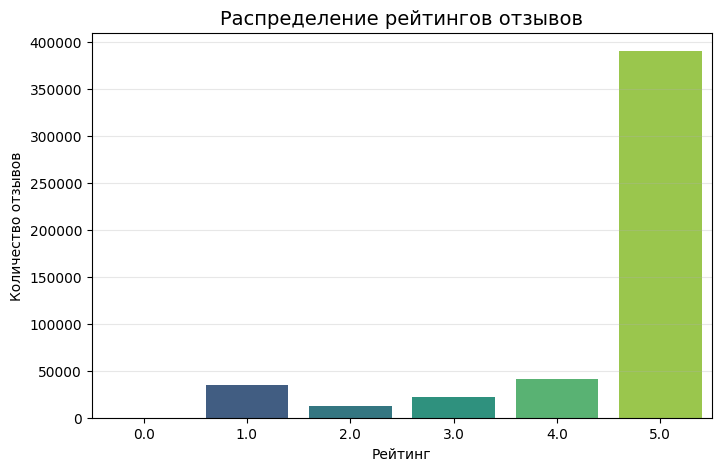

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=data, palette='viridis')

plt.title('Распределение рейтингов отзывов', fontsize=14)
plt.xlabel('Рейтинг')
plt.ylabel('Количество отзывов')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Блок 4. Загрузка модели и токенизатора

In [21]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

In [47]:
model_name = "DeepPavlov/rubert-base-cased-conversational"

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 39800.99it/s]
BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UN

In [48]:
def tokenize_function(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=192
    )

In [49]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
        'precision_macro': precision_score(labels, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
    }

# Блок 5. Подготовка данных к обучению

In [25]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

In [26]:
dataset = data[['rating', 'text', 'clean_text']]

In [27]:
rating_map = {
    0.0: 'negative',
    1.0: 'negative',
    2.0: 'negative',
    3.0: 'neutral',
    4.0: 'positive',
    5.0: 'positive'
}

label2id = {
    'positive': 0,
    'neutral': 1,
    'negative': 2,
}

id2label = {
    0: 'positive',
    1: 'neutral',
    2: 'negative',
}

In [28]:
dataset['label_text'] = data['rating'].map(rating_map)
dataset['label'] = dataset['label_text'].map(label2id)

In [29]:
dataset.head(5)

,rating,text,clean_text,label_text,label
0,3.0,Московский квартал 2.\nШумно : летом по ночам ...,московский квартал шумно лето по ночь дикий го...,neutral,1
1,5.0,"Замечательная сеть магазинов в общем, хороший ...",замечательный сеть магазин в общий хороший асс...,positive,0
2,1.0,"Не знаю смутят ли кого-то данные правила, но я...",не знать смутить ли кто то дать правило но я б...,negative,2
3,4.0,Хорошие условия аренды. \nДружелюбный персонал...,хороший условие аренда дружелюбный персонал но...,positive,0
4,5.0,Топ мастер Ангелина топ во всех смыслах ) Немн...,топ мастер ангелина топ в весь смысл немного в...,positive,0


# Блок 6. Обучение модели

## Трансферное обучение, нейросетевая архитектура

In [171]:
from transformers import EarlyStoppingCallback
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

`Приведение датафрейма к Dataset-типу`

In [66]:
df_class_0 = dataset[dataset['label'] == 0]
df_class_1 = dataset[dataset['label'] == 1]
df_class_2 = dataset[dataset['label'] == 2]

# Урезаем мажоритарный класс до 100 000 записей (случайная выборка)
df_class_0_downsampled = df_class_0.sample(n=100000, random_state=SEED)

# Объединяем обратно и перемешиваем
balanced_df = pd.concat([df_class_0_downsampled, df_class_1, df_class_2]).sample(frac=1, random_state=SEED)

In [69]:
balanced_df['label'].value_counts()

label
0    100000
2     46639
1     21686
Name: count, dtype: int64

In [72]:
train_dataset, eval_dataset = train_test_split(balanced_df, test_size=0.1, stratify=y, random_state=SEED)

train_data = Dataset.from_pandas(train_dataset[['text', 'label']].reset_index(drop=True))
eval_data = Dataset.from_pandas(eval_dataset[['text', 'label']].reset_index(drop=True))

train_data = train_data.map(tokenize_function, batched=True)
eval_data = eval_data.map(tokenize_function, batched=True)

train_data = train_data.remove_columns(column_names=['text'])
eval_data = eval_data.remove_columns(column_names=['text'])

Map: 100%|██████████| 16833/16833 [00:01<00:00, 14822.77 examples/s]


In [ ]:
# class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1, 2]), y=y_train)

In [59]:
for name, _ in model.named_modules():
    print(name)


bert
bert.embeddings
bert.embeddings.word_embeddings
bert.embeddings.position_embeddings
bert.embeddings.token_type_embeddings
bert.embeddings.LayerNorm
bert.embeddings.dropout
bert.encoder
bert.encoder.layer
bert.encoder.layer.0
bert.encoder.layer.0.attention
bert.encoder.layer.0.attention.self
bert.encoder.layer.0.attention.self.query
bert.encoder.layer.0.attention.self.key
bert.encoder.layer.0.attention.self.value
bert.encoder.layer.0.attention.self.dropout
bert.encoder.layer.0.attention.output
bert.encoder.layer.0.attention.output.dense
bert.encoder.layer.0.attention.output.LayerNorm
bert.encoder.layer.0.attention.output.dropout
bert.encoder.layer.0.intermediate
bert.encoder.layer.0.intermediate.dense
bert.encoder.layer.0.intermediate.intermediate_act_fn
bert.encoder.layer.0.output
bert.encoder.layer.0.output.dense
bert.encoder.layer.0.output.LayerNorm
bert.encoder.layer.0.output.dropout
bert.encoder.layer.1
bert.encoder.layer.1.attention
bert.encoder.layer.1.attention.self
bert.e

In [86]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,     
    lora_alpha=24,
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "dense"]
)

In [87]:
peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 2,681,091 || all params: 180,536,838 || trainable%: 1.4851


In [88]:
class FocalLossTrainer(Trainer):
    def __init__(self, *args, alpha=None, gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha # Базовые веса классов (опционально)
        self.gamma = gamma

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Получаем вероятности
        probs = F.softmax(logits, dim=-1)
        
        # Собираем вероятности только для правильных классов
        # view(-1, 1) делает тензор двумерным для функции gather
        p_t = probs.gather(1, labels.view(-1, 1)).view(-1)
        
        # Классическая кросс-энтропия
        ce_loss = -torch.log(p_t + 1e-10) # 1e-10 для предотвращения log(0)
        
        # Применяем Focal Loss фактор
        focal_loss = ((1 - p_t) ** self.gamma) * ce_loss
        
        # Опционально добавляем alpha (если решили совместить с весами)
        if self.alpha is not None:
            alpha_t = self.alpha.to(model.device).gather(0, labels.view(-1))
            focal_loss = focal_loss * alpha_t

        loss = focal_loss.mean()
        
        return (loss, outputs) if return_outputs else loss

In [89]:
training_args = TrainingArguments(
    output_dir="./output",
    per_device_train_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=2000,          
    save_strategy="steps",
    save_steps=2000,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
)

In [90]:
trainer = FocalLossTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    gamma=2.0 # Классическое значение из оригинальной статьи Lin et al.
)

In [91]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
2000,0.142386,0.132802,0.866453,0.767508,0.863923,0.771120,0.767464
4000,0.135534,0.120320,0.872394,0.778490,0.870770,0.780352,0.778606
6000,0.131718,0.127309,0.868235,0.774040,0.867491,0.773538,0.777630
8000,0.097717,0.116843,0.876908,0.777704,0.872420,0.788109,0.773539


TrainOutput(global_step=8000, training_loss=0.13321379977464676, metrics={'train_runtime': 1430.9027, 'train_samples_per_second': 317.615, 'train_steps_per_second': 19.853, 'total_flos': 1.302478700544e+16, 'train_loss': 0.13321379977464676, 'epoch': 0.8448621818565847})

In [224]:
text = "Это просто отличный товар, всем советую!"
inputs = tokenizer(
    text,
    return_tensors="pt", 
    padding=True,
    truncation=True,
    max_length=192
)
inputs = {k: v.to(peft_model.device) for k, v in inputs.items()}


peft_model.eval()
with torch.no_grad():
    outputs = peft_model(**inputs)
    logits = outputs.logits

pred_id = torch.argmax(logits, dim=-1).item()

probs = F.softmax(logits, dim=-1)
confidence = probs[0][pred_id].item()
all_probs = probs[0].tolist()

In [225]:
print(id2label[pred_id], confidence, "\n", all_probs)

positive 0.7998176217079163 
 [0.7998176217079163, 0.04965834319591522, 0.1505240499973297]


In [164]:
from torch.utils.data import DataLoader
import torch

In [167]:
eval_data

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 16833
})

In [172]:
eval_data.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

eval_dataloader = DataLoader(eval_data, batch_size=32)

all_preds = []
all_labels = []

device = next(peft_model.parameters()).device
peft_model.eval()

with torch.no_grad():
    for batch in tqdm(eval_dataloader, desc="Инференс"):
        # переносим на устройство только то, что уже является тензором
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = peft_model(**batch)
        
        # предсказания
        preds = torch.argmax(outputs.logits, dim=-1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['label'].cpu().numpy())

Начинаю инференс...


Evaluating: 100%|██████████| 527/527 [00:59<00:00,  8.93it/s]

Инференс завершен.



In [176]:
id2label

{0: 'positive', 1: 'neutral', 2: 'negative'}

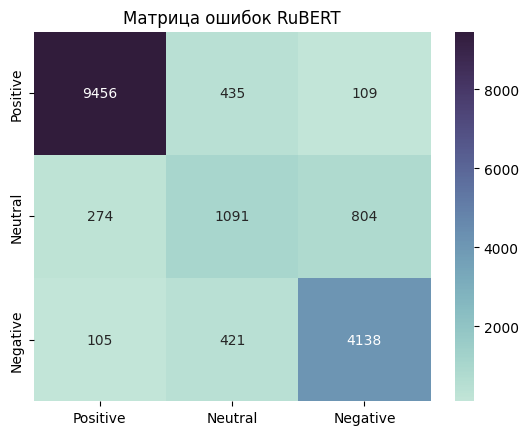

In [183]:
cmap = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
plt.title("Матрица ошибок RuBERT")
matrix = confusion_matrix(y_pred=all_preds, y_true=all_labels)
sns.heatmap(matrix, annot=True, fmt='d', cmap=cmap,
           xticklabels=['Positive', 'Neutral', 'Negative'], 
           yticklabels=['Positive', 'Neutral', 'Negative'])
plt.show()

In [116]:
# Сохранение модели и токенизатора
trainer.save_model("./best_mlp")
tokenizer.save_pretrained("./best_mlp")

('./best_mlp\\tokenizer_config.json', './best_mlp\\tokenizer.json')

## Классическое машинное обучение. Случайный лес.

In [159]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

`Для поиска лучших параметров использую только 10000 примеров из каждой группы отзывов`

In [152]:
balanced_data = (
    dataset.groupby('label')
    .sample(n=10000, random_state=SEED)
    .reset_index(drop=True)
)
X = dataset['clean_text']
y = dataset['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED, stratify=y, shuffle=True)

`Загрузка токенизатора с заранее инициализированными стоп-словами`

In [155]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words=stopwords)

`Токенизация входных данных (текста отзывов)`

In [156]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [157]:
# Из каких параметров будет выбор
model_params = {
    "n_estimators": [1000, 2000, 2500, 4000],
    "max_depth": [8, 12, 16, 24, 32],
    "min_samples_leaf": [1, 2, 3, 6],
    "min_samples_split": [2, 4, 6, 9]
}

In [160]:
# Инициализация модели
model = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    verbose=0,
    random_state=SEED
)

In [161]:
# Инициализация системы поиска наилучших параметров через кросс-валидацию (cv=3)
searcher = RandomizedSearchCV(model, cv=3, n_iter=50, random_state=SEED, param_distributions=model_params, scoring='f1_macro')

`Поиск лучших параметров модели`

In [162]:
searcher.fit(X_train_vec, y_train)

KeyboardInterrupt: 

`Проверка текущей метрики (F1-score) до основного обучения`

In [ ]:
best_model = searcher.best_estimator_
preds = model.predict(X_test_vec)
f1_score(preds, y_test, average='macro')

In [ ]:
print(classification_report(preds, y_test))

In [ ]:
# Инициализация модели с заранее определенными параметрами
rfc = RandomForestClassifier(**searcher.best_params_, n_jobs=-1, random_state=SEED, class_weight='balanced')

`Инициализация, разбиение и токенизация всех данных`

In [89]:
X = dataset['clean_text']
y = dataset['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED, stratify=y, shuffle=True)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [218]:
rfc.fit(X_train_vec, y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,32
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [219]:
preds = rfc.predict(X_test_vec)

0.6025945291661042

In [ ]:
print(f"F1-score: {f1_score(y_true=y_test, y_pred=preds, average='macro')}")
print(f"precision_score: {precision_score(y_test, preds, average='macro')}")
print(f"recall_score: {recall_score(y_test, preds, average='macro')}")

## Градиентный бустинг (модель от Яндекса: CatBoost)

In [30]:
from catboost import CatBoostClassifier
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [31]:
stopwords = stopwords.words('russian')

In [32]:
balanced_data = (
    dataset.groupby('label')
    .sample(n=20000, random_state=SEED)
    .reset_index(drop=True)
)

In [33]:
X_cb = dataset['clean_text']
y_cb = dataset['label']

In [34]:
X_train, X_temp, y_train, y_temp = train_test_split(X_cb, y_cb, test_size=0.2, random_state=SEED, stratify=y_cb, shuffle=True)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp, shuffle=True)

In [35]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words=stopwords)

In [36]:
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

In [37]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1, 2]), y=y_train)

In [38]:
class_weights

array([0.38609309, 7.68534209, 3.5735574 ])

In [39]:
params = {
    "iterations": 2000,
    "depth": 8,
    "l2_leaf_reg": 5,
    "early_stopping_rounds": 50,
}

In [42]:
model = CatBoostClassifier(
    **params,
    eval_metric='TotalF1:average=Macro;use_weights=False',
    class_weights=class_weights,
    thread_count=-1,
    random_state=SEED,
    task_type='GPU', 
    verbose=100
)

In [43]:
model.fit(X_train_vec, y_train, eval_set=(X_val_vec, y_val))

0:	learn: 0.4090724	test: 0.4085694	best: 0.4085694 (0)	total: 677ms	remaining: 22m 33s
100:	learn: 0.5255848	test: 0.5230190	best: 0.5231953 (99)	total: 58.4s	remaining: 18m 17s
200:	learn: 0.5629207	test: 0.5586086	best: 0.5586086 (200)	total: 1m 47s	remaining: 16m 2s
300:	learn: 0.5827095	test: 0.5769628	best: 0.5769628 (300)	total: 2m 38s	remaining: 14m 52s
400:	learn: 0.5961590	test: 0.5881435	best: 0.5881435 (400)	total: 3m 13s	remaining: 12m 52s
500:	learn: 0.6058879	test: 0.5958322	best: 0.5958519 (499)	total: 3m 41s	remaining: 11m 4s
600:	learn: 0.6140353	test: 0.6013920	best: 0.6013920 (600)	total: 4m 9s	remaining: 9m 41s
700:	learn: 0.6203894	test: 0.6056496	best: 0.6056496 (700)	total: 4m 37s	remaining: 8m 33s
800:	learn: 0.6262332	test: 0.6101815	best: 0.6101815 (800)	total: 5m 4s	remaining: 7m 35s
900:	learn: 0.6310517	test: 0.6137830	best: 0.6138760 (897)	total: 5m 30s	remaining: 6m 43s
1000:	learn: 0.6350125	test: 0.6171998	best: 0.6171998 (1000)	total: 5m 57s	remaining

CatBoostClassifier(class_weights=array([0.38609309, 7.68534209, 3.5735574 ]), depth=8, early_stopping_rounds=50, eval_metric='TotalF1:average=Macro;use_weights=False', iterations=2000, l2_leaf_reg=5, random_state=42, task_type='GPU', verbose=100)

In [125]:
model.save_model("gradient_boosting_743.cbm")

In [44]:
preds = model.predict(X_test_vec)

In [45]:
print(f"F1-score: {f1_score(y_true=y_test, y_pred=preds, average='macro')}")
print(f"precision_score: {precision_score(y_test, preds, average='macro')}")
print(f"recall_score: {recall_score(y_test, preds, average='macro')}")

F1-score: 0.6385988963774242
precision_score: 0.6223153746774291
recall_score: 0.7473033535814294


<Axes: >

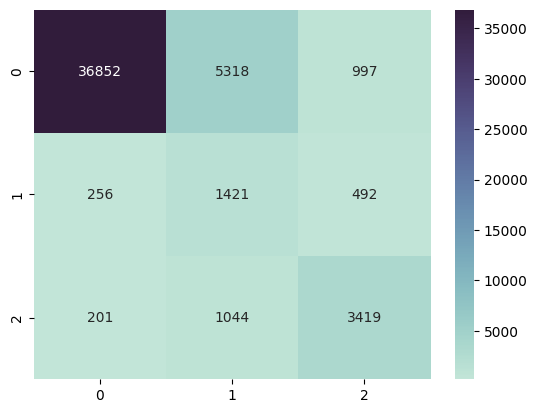

In [46]:
cmap = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)

matrix = confusion_matrix(y_pred=preds, y_true=y_test)
sns.heatmap(matrix, annot=True, fmt='d', cmap=cmap)